**Import**

In [70]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns
np.random.seed(0)


# Data

In [71]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [72]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


**Visualize Examples**

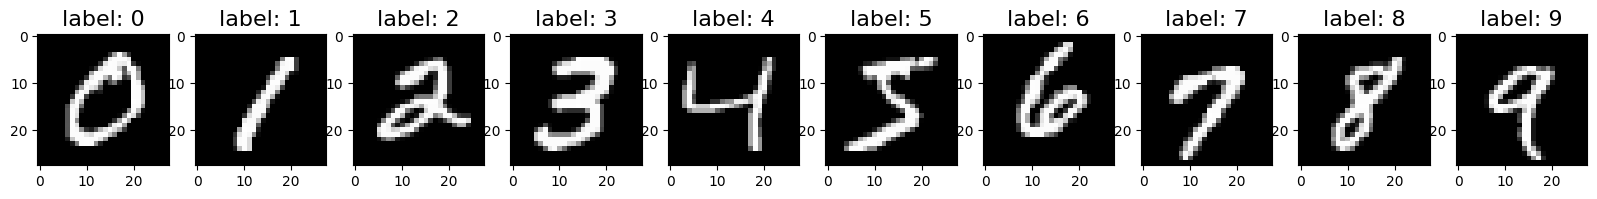

In [73]:
num_classes = 10
f, ax = plt.subplots(1, num_classes, figsize = (20,20))
for i in range(0, num_classes):
  sample = x_train[y_train == i][0]
  ax[i].imshow(sample, cmap ='gray')
  ax[i].set_title("label: {}".format(i), fontsize=16)

In [74]:
for i in range(10):
  print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [75]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [76]:
for i in range(10):
  print(y_train[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


**Prepare Data**

In [77]:
#normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0


In [78]:
# Reshape Data
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape)

(60000, 784)


**Create model - Fully Connected Neural Network**

In [79]:
model = Sequential()
model.add(Dense(units=128, input_shape=(784,), activation = 'relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

**Training**

In [80]:
batch_size=512
epochs = 10
history = model.fit(x= x_train, y= y_train, batch_size =batch_size, epochs=epochs, validation_split=0.1 )

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8163 - loss: 0.6295 - val_accuracy: 0.9403 - val_loss: 0.2110
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9301 - loss: 0.2427 - val_accuracy: 0.9590 - val_loss: 0.1442
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9468 - loss: 0.1812 - val_accuracy: 0.9677 - val_loss: 0.1204
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9579 - loss: 0.1442 - val_accuracy: 0.9692 - val_loss: 0.1051
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9651 - loss: 0.1185 - val_accuracy: 0.9728 - val_loss: 0.0927
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9697 - loss: 0.1022 - val_accuracy: 0.9747 - val_loss: 0.0851
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9742 - loss: 0.0864 - val_accuracy: 0.9760 - val_loss: 0.0834
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9769 - loss: 0.0769 - val_accu

**Evaluate**

In [81]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Loss: {}, Test Accuracy: {}".format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9765 - loss: 0.0756
Test Loss: 0.07562940567731857, Test Accuracy: 0.9764999747276306


In [82]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred)
print(y_pred_classes)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[4.89741467e-07 9.19570624e-08 2.05886681e-04 ... 9.98892665e-01
  5.34068568e-06 2.97731276e-05]
 [4.24062335e-07 1.76876609e-04 9.99799013e-01 ... 5.77072150e-08
  1.64644061e-05 3.61859209e-10]
 [1.06283851e-05 9.94484127e-01 6.75919291e-04 ... 2.67500477e-03
  1.46110903e-03 9.57706652e-05]
 ...
 [7.52080953e-10 1.28831712e-09 3.30156735e-10 ... 4.81282996e-07
  1.01056486e-07 1.57782836e-06]
 [1.54941245e-06 2.24262962e-07 4.35773728e-09 ... 7.93762979e-07
  3.64236330e-04 3.12410037e-07]
 [5.06292110e-08 7.21499915e-10 1.42462056e-07 ... 1.92817862e-11
  3.21670662e-10 8.58809412e-11]]
[7 2 1 ... 4 5 6]


In [83]:
y_true = np.argmax(y_test, axis=1)

 **Single Example**

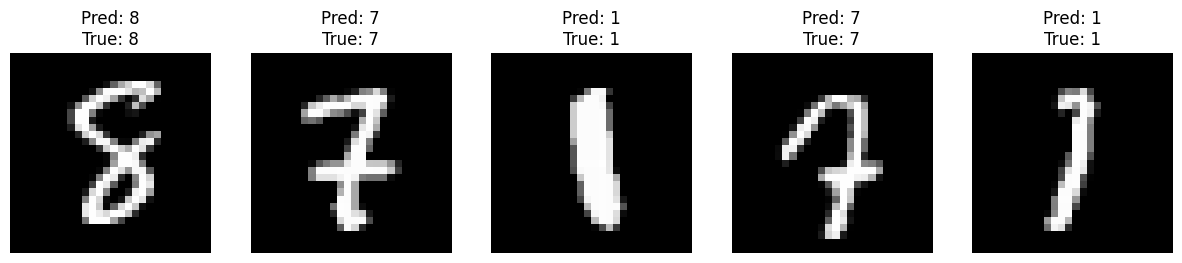

In [84]:
random_idxs = np.random.choice(len(x_test), 5, replace=False)
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(random_idxs):
    ax[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    ax[i].set_title("Pred: {}\nTrue: {}".format(y_pred_classes[idx], y_true[idx]), fontsize=12)
    ax[i].axis('off')
plt.show()

**Confusion Matrix**

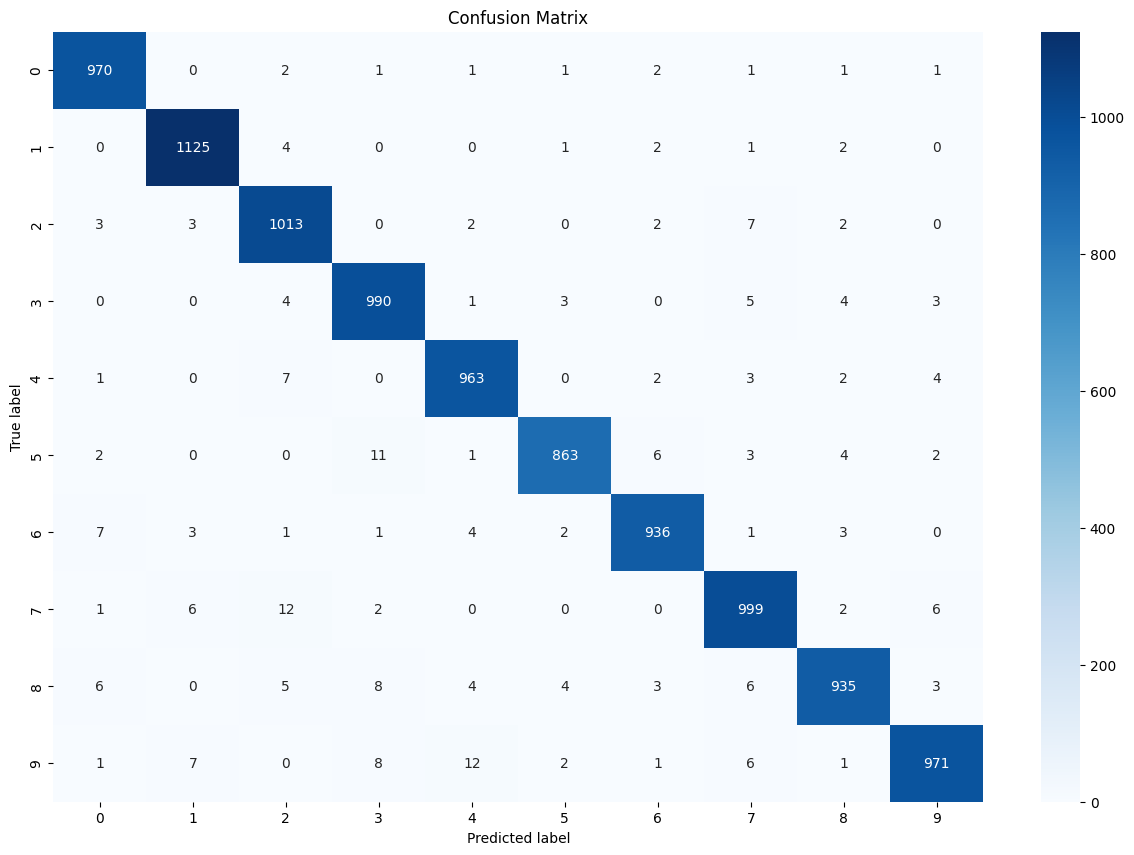

In [85]:
confusion_mtx = confusion_matrix(y_true, y_pred_classes)
#PLOT
fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")
plt.show()



**Investigate Errors**

In [86]:
errors =(y_pred_classes - y_true != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_pred_errors = y_pred[errors]
y_true_errors = y_true[errors]
x_test_errors = x_test[errors]

In [87]:
y_pred_errors_probability = np.max(y_pred_errors, axis=1)
true_probability_errors = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1 ))
diff_errors_pred_true = y_pred_errors_probability - true_probability_errors
# get list of indices of sorted differences
sorted_idx_diff_errors = np.argsort(diff_errors_pred_true)
top_idx_diff_errors = sorted_idx_diff_errors[-5:] # 5 last ones


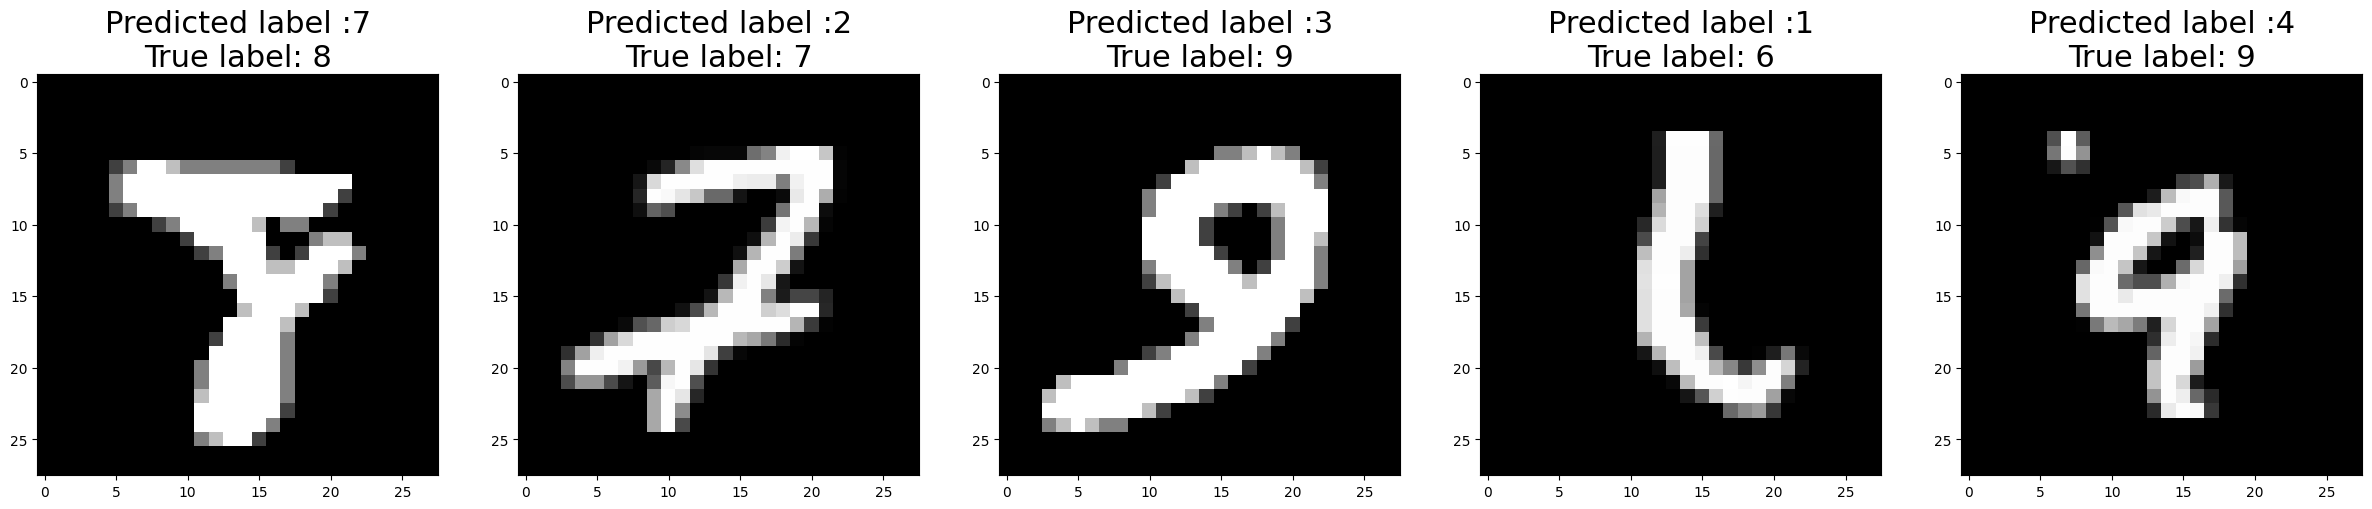

In [88]:
num = len(top_idx_diff_errors)
f, ax = plt.subplots(1, num, figsize=(30,30))
for i in range(0, num):
  idx= top_idx_diff_errors[i]
  sample = x_test_errors[idx].reshape(28,28)
  y_t = y_true_errors[idx]
  y_p = y_pred_classes_errors[idx]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title("Predicted label :{}\nTrue label: {}".format(y_p, y_t), fontsize=22)

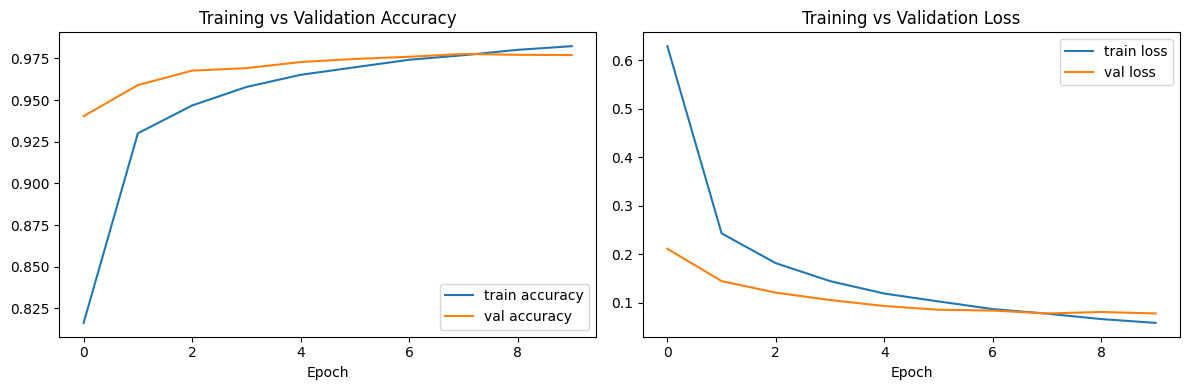

In [89]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()

In [90]:
# EXPERIMENT: change ONE thing — number of neurons per hidden layer (128 -> 256)
# Everything else (2 hidden layers, relu, Dropout(0.25), optimizer, batch_size, epochs) is unchanged
model2 = Sequential()
model2.add(Dense(units=256, input_shape=(784,), activation='relu'))
model2.add(Dense(units=256, activation='relu'))
model2.add(Dropout(0.25))
model2.add(Dense(units=10, activation='softmax'))
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()
history2 = model2.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
test_loss2, test_acc2 = model2.evaluate(x_test, y_test)
print("Test Loss: {}, Test Accuracy: {}".format(test_loss2, test_acc2))
print("Original (128 neurons/layer)   -> Test Accuracy: {:.4f}, Test Loss: {:.4f}".format(test_acc, test_loss))
print("Experiment (256 neurons/layer) -> Test Accuracy: {:.4f}, Test Loss: {:.4f}".format(test_acc2, test_loss2))
print("Change in test accuracy: {:+.4f}".format(test_acc2 - test_acc))
print("Change in test loss:     {:+.4f}".format(test_loss2 - test_loss))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8584 - loss: 0.4973 - val_accuracy: 0.9558 - val_loss: 0.1631
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9449 - loss: 0.1865 - val_accuracy: 0.9678 - val_loss: 0.1145
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9621 - loss: 0.1299 - val_accuracy: 0.9720 - val_loss: 0.0988
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9708 - loss: 0.0970 - val_accuracy: 0.9727 - val_loss: 0.0834
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9775 - loss: 0.0756 - val_accuracy: 0.9765 - val_loss: 0.0795
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9816 - loss: 0.0603 - val_accuracy: 0.9788 - val_loss: 0.0746
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9845 - loss: 0.0513 - val_accuracy: 0.9793 - val_loss: 0.0702
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9875 - loss: 0.0409 - val_accu

**Comparison Before vs After change**

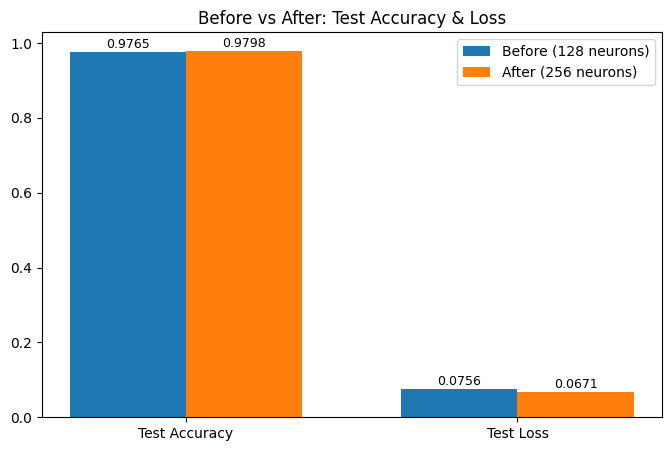

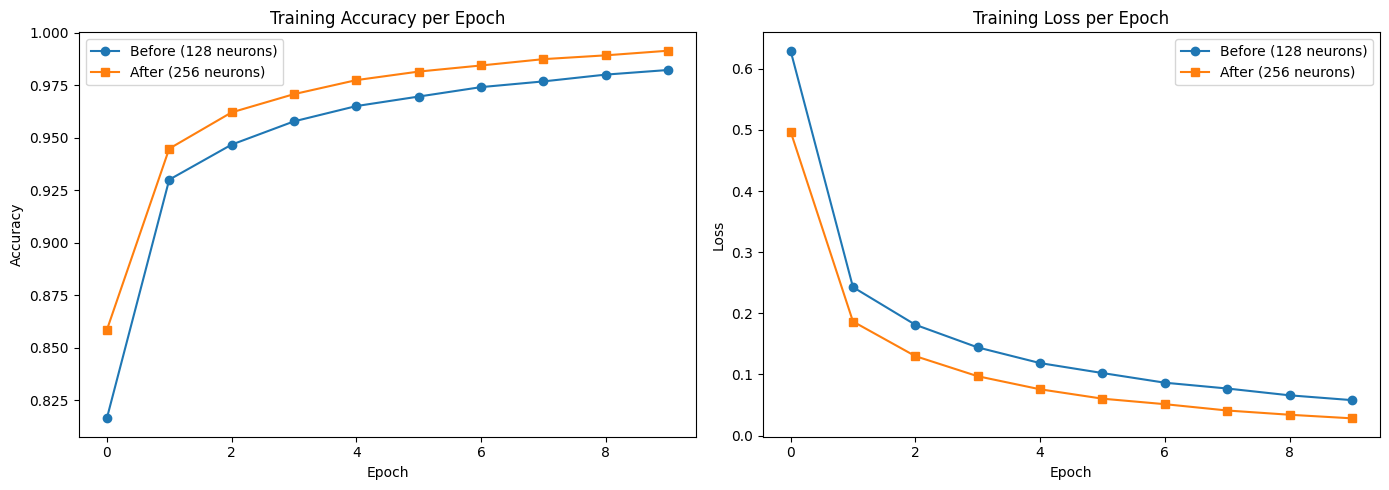

Metric                      Before (128)    After (256)
-------------------------------------------------------
Params                            118282         269322
Final train accuracy              0.9824         0.9915
Final train loss                  0.0579         0.0281
Test accuracy                     0.9765         0.9798
Test loss                         0.0756         0.0671
-------------------------------------------------------
Change in test accuracy: +0.0033
Change in test loss:     -0.0085


In [91]:
# BEFORE vs AFTER COMPARISON: 128 neurons vs 256 neurons per hidden layer =====
# Bar chart: test accuracy and test loss side by side
labels = ['Test Accuracy', 'Test Loss']
before_vals = [test_acc, test_loss]
after_vals = [test_acc2, test_loss2]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, before_vals, width, label='Before (128 neurons)')
ax.bar(x + width/2, after_vals, width, label='After (256 neurons)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Before vs After: Test Accuracy & Loss")
ax.legend()
for i, v in enumerate(before_vals):
    ax.text(i - width/2, v + 0.01, "{:.4f}".format(v), ha='center', fontsize=9)
for i, v in enumerate(after_vals):
    ax.text(i + width/2, v + 0.01, "{:.4f}".format(v), ha='center', fontsize=9)
plt.show()
# 2. Training accuracy and loss curves, before vs after
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['accuracy'], marker='o', label='Before (128 neurons)')
ax[0].plot(history2.history['accuracy'], marker='s', label='After (256 neurons)')
ax[0].set_title("Training Accuracy per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(history.history['loss'], marker='o', label='Before (128 neurons)')
ax[1].plot(history2.history['loss'], marker='s', label='After (256 neurons)')
ax[1].set_title("Training Loss per Epoch")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.tight_layout()
plt.show()
# 3. Summary table printed to console
print("{:<25}{:>15}{:>15}".format("Metric", "Before (128)", "After (256)"))
print("-" * 55)
print("{:<25}{:>15}{:>15}".format("Params", model.count_params(), model2.count_params()))
print("{:<25}{:>15.4f}{:>15.4f}".format("Final train accuracy", history.history['accuracy'][-1], history2.history['accuracy'][-1]))
print("{:<25}{:>15.4f}{:>15.4f}".format("Final train loss", history.history['loss'][-1], history2.history['loss'][-1]))
print("{:<25}{:>15.4f}{:>15.4f}".format("Test accuracy", test_acc, test_acc2))
print("{:<25}{:>15.4f}{:>15.4f}".format("Test loss", test_loss, test_loss2))
print("-" * 55)
print("Change in test accuracy: {:+.4f}".format(test_acc2 - test_acc))
print("Change in test loss:     {:+.4f}".format(test_loss2 - test_loss))